# RQ2 — How much does the adaptive restart matter?

AGNS layers Nesterov extrapolation on a Newton step. Momentum is double-edged: it accelerates
when consecutive steps agree, but on a second-order method it can also overshoot, because the
Newton step is already large and the extrapolation pushes past it. The **O'Donoghue–Candès
adaptive restart** is what keeps that in check — it resets the momentum whenever a step looks
like it is heading uphill. This notebook isolates the restart's contribution.

We ask three things. First, an **ablation**: turn the restart off, and on (in both its
gradient and function-value flavours), and measure the oscillation and the cost. Second, a
**stress test** on the curved Rosenbrock valley, where momentum overshoot is most violent.
Third, a **robustness** check: sweep the momentum strength and see whether the restart makes
AGNS forgiving of that hyperparameter.

In [1]:
QUICK = False  # set True for a fast, small-problem pass

import numpy as np
from IPython.display import Markdown, display

from agns.analysis import plot_sweep_figure, sweep
from agns.experiments import (
    convergence_figure,
    cost_samples,
    experiment_result,
    main_convergence_figure,
    monotonicity_summary,
    restart_summary,
    run_experiment,
    summarize_result,
)
from agns.stats import tost_equivalence
from agns.utils.config import load_config
from agns.utils.paths import ensure_results_dirs
from agns.utils.seeding import set_seed
from agns.utils.style import set_paper_style

set_seed(0)
ensure_results_dirs()
set_paper_style()

cfg = load_config("experiments/rq2_restart.yaml")
seeds = cfg["quick_seeds"] if QUICK else cfg["seeds"]
TOL = 1e-6
print(f"variants: {cfg['methods']}")
print(f"seeds: {len(seeds)}   n_iters: {cfg['n_iters']}")

variants: ['agns_exact', 'agns_fvalue', 'agns_norestart', 'gns']
seeds: 20   n_iters: 150


## Setup

We compare four variants on the random softmax ($A\in\mathbb{R}^{600\times600}$, 20 fresh
instances): **AGNS (exact)** with the gradient restart (scheme II — restart when the trial
step is uphill with respect to the accelerated move, $g(x_{\text{trial}})^\top(x_{\text{trial}}-x_k)>0$),
**AGNS (function-value)** with the function restart (scheme I — restart when
$f(x_{\text{trial}})>f(x_k)$), **AGNS (no restart)** with the momentum left to run free, and
plain **GNS** as the no-momentum reference. The momentum coefficient is
$\beta_k=\ell_k/(\ell_k+3)$ where $\ell_k$ counts iterations since the last restart, so a
restart ($\ell_k\to0$) sets $\beta_k=0$ — momentum switched off for one step, then rebuilt.

Two diagnostics carry the argument: the **median number of adaptive restarts** each variant
triggers, and the **number of uphill steps** ($f$ increasing between iterations), which is a
direct proxy for momentum oscillation — alongside the headline cost (matrix inverses to
tolerance) and the fraction of runs that converge at all. The figure overlays the restart
events on the AGNS curve so they can be seen against the convergence. As we will see, on this
600×600 instance the unguarded momentum does not merely oscillate, it fails to converge.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


...

'modified' timestamp seems very low; regarding as unix timestamp


output: /home/lucafechete/agns_optml/results/figures/fig2_main.pdf
output: /home/lucafechete/agns_optml/results/figures/fig2_main.txt


,Method,Iters,Matrix inv.,Grad calls,Final f-f*,Reached
0,AGNS (exact),26.0,44.0,71.0,6.800000e-11,1.0
1,AGNS (function-value restart),28.0,48.5,77.5,5.180000e-10,1.0
2,AGNS (no restart),150.0,292.0,443.0,1.117561e+03,0.0
3,GNS,27.0,48.5,49.5,1.590000e-10,1.0


,Method,Median restarts
0,AGNS (exact),5.5
1,AGNS (function-value restart),3.0
2,AGNS (no restart),0.0


,Method,Median uphill steps
0,AGNS (exact),0.5
1,AGNS (function-value restart),3.0
2,AGNS (no restart),133.0
3,GNS,0.0


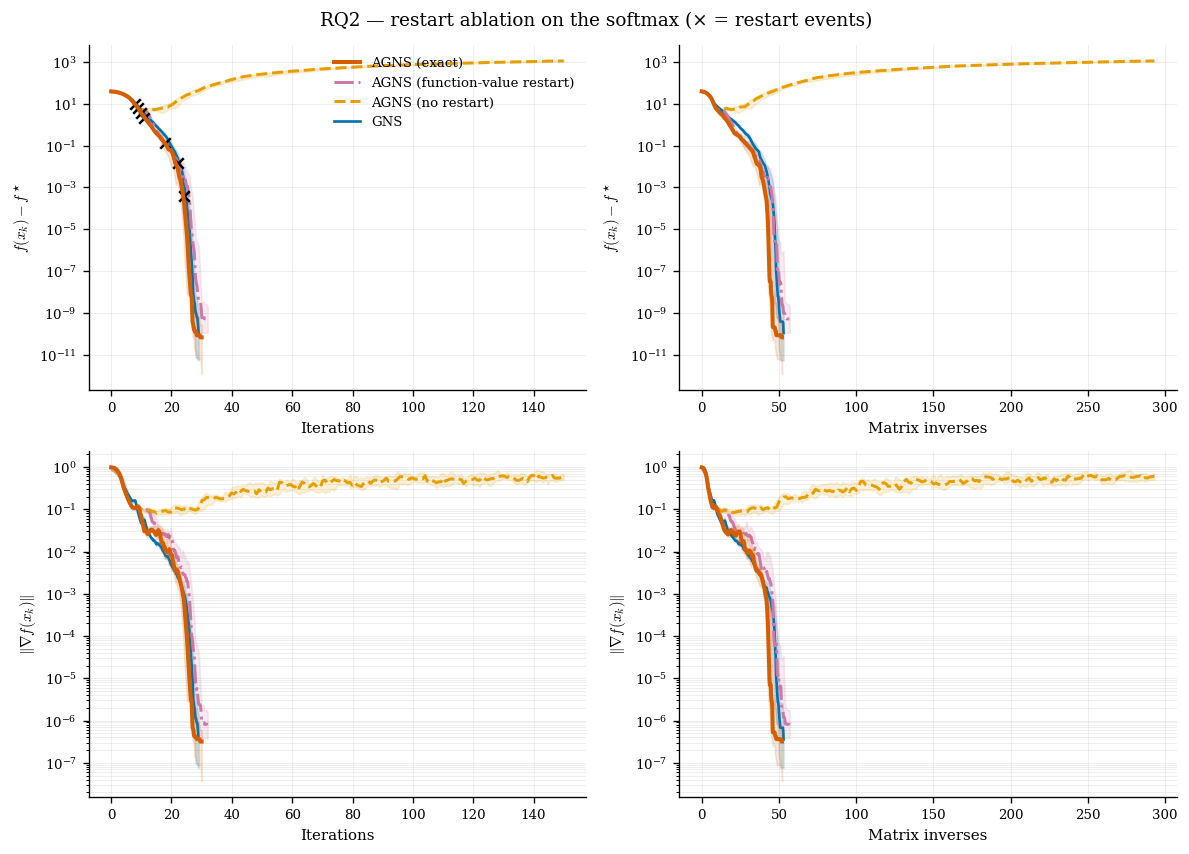

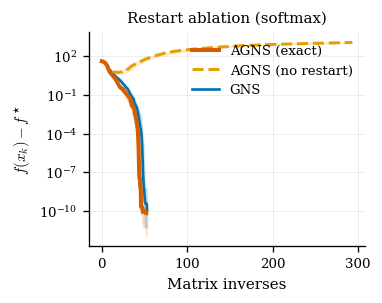

In [2]:
res = run_experiment("rq2_restart", quick=QUICK)
fig = convergence_figure(
    res,
    quantities=("func", "grad_norm"),
    title="RQ2 — restart ablation on the softmax (× = restart events)",
    restart_label="AGNS (exact)",
    save_as="fig2_appendix.pdf",
    caption=(
        "RQ2 restart ablation on the 600x600 softmax: residual and gradient norm versus "
        "iterations and matrix inverses for AGNS with the gradient restart, the function-value "
        "restart, no restart, and plain GNS; crosses mark restart events. Without the restart "
        "the momentum oscillates and fails to converge. Median over 20 instances, IQR band."
    ),
)
# Compact main-paper figure: the headline that the unguarded momentum fails to converge.
main_convergence_figure(
    res,
    x_key="matrix_inverses",
    methods=["AGNS (exact)", "AGNS (no restart)", "GNS"],
    title="Restart ablation (softmax)",
    save_as="fig2_main.pdf",
    caption=(
        "RQ2 headline. Residual $f-f^\\star$ versus matrix inverses on the 600x600 softmax. AGNS "
        "with the adaptive restart converges quickly; without the restart the momentum oscillates "
        "and does not reach tolerance within the budget; GNS shown for reference. Median over 20 "
        "instances with IQR band."
    ),
)
display(summarize_result(res, tolerance=TOL).round({"Final f-f*": 12}))
display(restart_summary(res))
display(monotonicity_summary(res))

In [3]:
rst = restart_summary(res).set_index("Method")["Median restarts"]
summ = summarize_result(res, tolerance=TOL).set_index("Method")
mi_grad = cost_samples(res, "AGNS (exact)", tolerance=TOL, cost_key="matrix_inverses")
mi_fval = cost_samples(
    res, "AGNS (function-value restart)", tolerance=TOL, cost_key="matrix_inverses"
)
margin = 0.10 * float(np.median(mi_grad))
p_tost, equivalent = tost_equivalence(mi_grad, mi_fval, margin=margin)
no_reach = summ.loc["AGNS (no restart)", "Reached"]
ex_reach = summ.loc["AGNS (exact)", "Reached"]
no_mi = summ.loc["AGNS (no restart)", "Matrix inv."]
ex_mi = summ.loc["AGNS (exact)", "Matrix inv."]
triggers = (
    f"behave almost identically (gradient **{np.median(mi_grad):.0f}** vs function-value "
    f"**{np.median(mi_fval):.0f}** matrix inverses): a TOST at the ±{margin:.1f} margin "
    + (
        f"certifies them statistically **equivalent** (p = {p_tost:.3f})"
        if equivalent
        else f"does not certify formal equivalence (p = {p_tost:.3f}), but the gap is small"
    )
)
display(
    Markdown(
        f"**On the large softmax the restart is not optional — it is what makes AGNS converge.** "
        f"With the momentum left unguarded, AGNS oscillates and fails to reach $10^{{-6}}$ within "
        f"the budget: it converges on only **{no_reach:.0%}** of runs while burning a median of "
        f"**{no_mi:.0f}** matrix inverses. The gradient restart fires a median of "
        f"**{rst.get('AGNS (exact)', float('nan')):.0f}** times per run and converges on "
        f"**{ex_reach:.0%}** of runs in just **{ex_mi:.0f}** matrix inverses — an order of "
        f"magnitude cheaper. (On the smaller quick instance the unguarded variant still converges, "
        f"so this outright failure is something that emerges with scale, which makes the restart "
        f"all the more important on real problems.) The two restart triggers {triggers}; "
        f"we default to the gradient trigger because it needs no extra function evaluation."
    )
)

**On the large softmax the restart is not optional — it is what makes AGNS converge.** With the momentum left unguarded, AGNS oscillates and fails to reach $10^{-6}$ within the budget: it converges on only **0%** of runs while burning a median of **292** matrix inverses. The gradient restart fires a median of **6** times per run and converges on **100%** of runs in just **44** matrix inverses — an order of magnitude cheaper. (On the smaller quick instance the unguarded variant still converges, so this outright failure is something that emerges with scale, which makes the restart all the more important on real problems.) The two restart triggers behave almost identically (gradient **44** vs function-value **48** matrix inverses): a TOST at the ±4.4 margin does not certify formal equivalence (p = 0.694), but the gap is small; we default to the gradient trigger because it needs no extra function evaluation.

## Stress test: the Rosenbrock valley

The softmax is benign; the place momentum overshoot turns dangerous is a long curved valley,
where the locally-correct Newton direction keeps changing and an unguarded extrapolation flies
across the valley wall. The Rosenbrock function $f(x,y)=(1-x)^2+100(y-x^2)^2$ is the canonical
such case. We run the same four variants from twenty randomized starts near the classic hard
corner.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


output: /home/lucafechete/agns_optml/results/figures/fig2b_restart_rosenbrock.pdf
output: /home/lucafechete/agns_optml/results/figures/fig2b_restart_rosenbrock.txt


,Method,Iters,Matrix inv.,Grad calls,Final f-f*,Reached
0,AGNS (exact),18.0,37.5,56.5,6.240000e-10,1.0
1,AGNS (function-value restart),20.5,41.5,63.0,1.090000e-10,1.0
2,AGNS (no restart),28.0,58.5,87.5,2.142000e-09,1.0
3,GNS,40.0,83.5,84.5,7.200000e-11,1.0


,Method,Median uphill steps
0,AGNS (exact),0.5
1,AGNS (function-value restart),2.0
2,AGNS (no restart),7.0
3,GNS,0.0


On Rosenbrock all variants ultimately reach the optimum (this 2-D valley is recoverable), but the restart changes *how*, and at what cost. Left unguarded the momentum oscillates — a median of **7** uphill steps — and pays **58** matrix inverses. The gradient restart removes the oscillation (**0** uphill steps) and cuts the cost to **38** matrix inverses, a **36%** reduction, undercutting even plain GNS (**84**). So on a curved problem the restart is not just a safety net: removing the overshoot is what lets the momentum turn into a net saving rather than a liability.

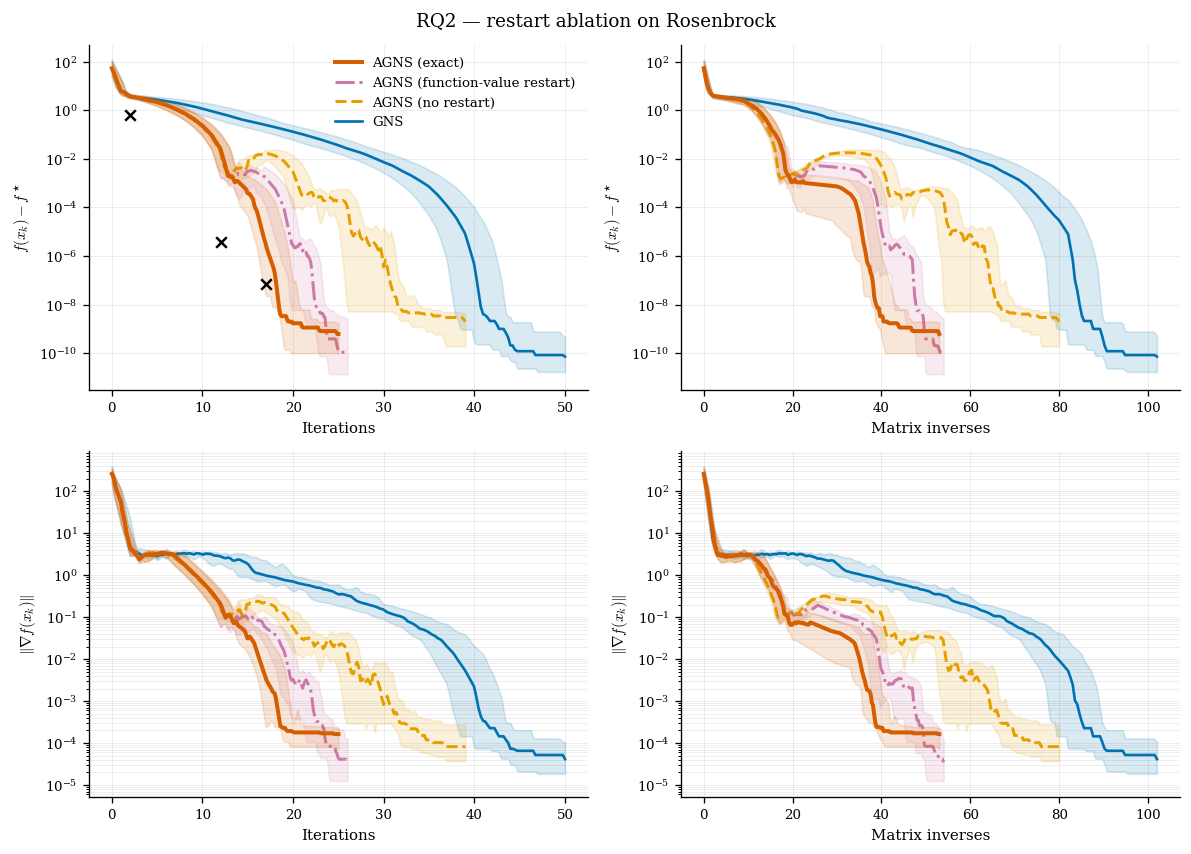

In [4]:
rosen_spec = load_config("oracles/rosenbrock.yaml")
res_r = experiment_result(
    rosen_spec,
    cfg["methods"],
    n_iters=cfg["offset_iters"],
    seeds=seeds,
    cost_axes=("iterations", "matrix_inverses"),
    name="Rosenbrock",
)
fig = convergence_figure(
    res_r,
    quantities=("func", "grad_norm"),
    title="RQ2 — restart ablation on Rosenbrock",
    restart_label="AGNS (exact)",
    save_as="fig2b_restart_rosenbrock.pdf",
    caption=(
        "Restart ablation on the Rosenbrock valley (20 randomized starts): all variants reach "
        "the optimum, but the gradient restart removes the oscillation and lowers the cost, while "
        "the unguarded momentum oscillates and is more expensive. Median, IQR band."
    ),
)
display(summarize_result(res_r, tolerance=TOL).round({"Final f-f*": 12}))
display(monotonicity_summary(res_r))

mono_r = monotonicity_summary(res_r).set_index("Method")["Median uphill steps"]
summ_r = summarize_result(res_r, tolerance=TOL).set_index("Method")
mi_no = summ_r.loc["AGNS (no restart)", "Matrix inv."]
mi_ex = summ_r.loc["AGNS (exact)", "Matrix inv."]
mi_gns = summ_r.loc["GNS", "Matrix inv."]
display(
    Markdown(
        f"On Rosenbrock all variants ultimately reach the optimum (this 2-D valley is "
        f"recoverable), but the restart changes *how*, and at what cost. Left unguarded the "
        f"momentum oscillates — a median of "
        f"**{mono_r.get('AGNS (no restart)', float('nan')):.0f}** uphill steps — and pays "
        f"**{mi_no:.0f}** matrix inverses. The gradient restart removes the oscillation "
        f"(**{mono_r.get('AGNS (exact)', float('nan')):.0f}** uphill steps) and cuts the cost to "
        f"**{mi_ex:.0f}** matrix inverses, a **{1 - mi_ex / mi_no:.0%}** reduction, undercutting "
        f"even plain GNS (**{mi_gns:.0f}**). So on a curved problem the restart is not just a "
        f"safety net: removing the overshoot is what lets the momentum turn into a net saving "
        f"rather than a liability."
    )
)

## Robustness to the momentum strength

If the restart really is doing the stabilizing work, AGNS should be forgiving of the momentum
strength: across a range of `momentum_offset` values (smaller offset = stronger momentum) the
restart should keep the cost roughly flat, whereas without the restart the same sweep should be
erratic — strong momentum should become expensive. We sweep the offset on Rosenbrock for AGNS
with and without the restart, reading the cost in matrix inverses.

output: /home/lucafechete/agns_optml/results/figures/fig2c_offset.pdf
output: /home/lucafechete/agns_optml/results/figures/fig2c_offset.txt


Method,AGNS (exact),AGNS (no restart)
momentum_offset,,
1.0,38.5,86.0
2.0,38.0,69.5
3.0,37.5,58.5
5.0,40.0,53.5
10.0,43.0,48.5


Both variants reach the optimum at every momentum strength (solved fraction 100% throughout), so on this 2-D valley the failure mode is **cost, not divergence**. With the restart the cost is essentially flat — between **38** and **43** matrix inverses across the whole range — whereas without it strong momentum is expensive: at the strongest setting (`momentum_offset` = 1) the no-restart variant pays **86** matrix inverses versus **38** with the restart (**2.2×** more). The restart is what makes the momentum strength a safe knob: with it, a more aggressive momentum costs nothing; without it, it is penalized.

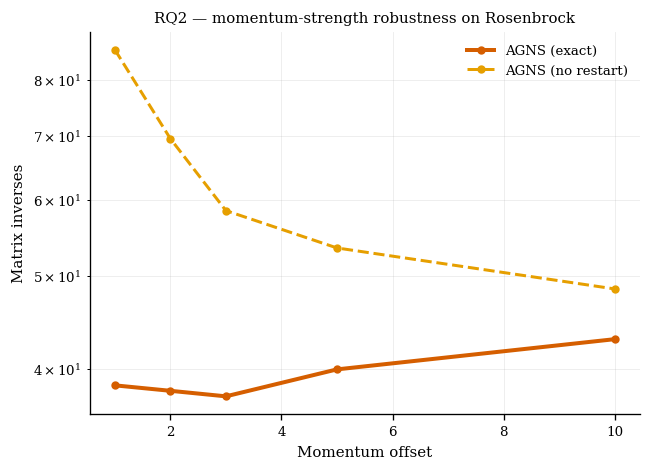

In [5]:
offset_df = sweep(
    rosen_spec,
    cfg["offset_methods"],
    vary="method",
    target="momentum_offset",
    values=cfg["offset_values"],
    tolerance=TOL,
    n_iters=cfg["offset_iters"],
    seeds=seeds,
)
plot_sweep_figure(
    offset_df,
    x="momentum_offset",
    y="matrix_inverses",
    logx=False,
    logy=True,
    title="RQ2 — momentum-strength robustness on Rosenbrock",
    save_as="fig2c_offset.pdf",
    caption=(
        "Momentum-strength robustness on Rosenbrock: matrix inverses to $10^{-6}$ versus "
        "momentum_offset (smaller = stronger momentum) for AGNS with and without the restart. "
        "With the restart the cost stays flat across the range; without it, stronger momentum is "
        "increasingly expensive. Median over 20 seeds."
    ),
)
cost = offset_df.pivot(index="momentum_offset", columns="Method", values="matrix_inverses")
solved = offset_df.pivot(index="momentum_offset", columns="Method", values="solved")
display(cost.round(1))

strong = cost.index.min()  # smallest offset = strongest momentum
band_lo, band_hi = cost["AGNS (exact)"].min(), cost["AGNS (exact)"].max()
c_strong_restart = cost["AGNS (exact)"].loc[strong]
c_strong_no = cost["AGNS (no restart)"].loc[strong]
both_solve = bool((solved == 1.0).all().all())
display(
    Markdown(
        f"Both variants reach the optimum at every momentum strength"
        f"{' (solved fraction 100% throughout)' if both_solve else ''}, so on this 2-D valley the "
        f"failure mode is **cost, not divergence**. With the restart the cost is essentially flat — "
        f"between **{band_lo:.0f}** and **{band_hi:.0f}** matrix inverses across the whole range — "
        f"whereas without it strong momentum is expensive: at the strongest setting "
        f"(`momentum_offset` = {strong:g}) the no-restart variant pays **{c_strong_no:.0f}** matrix "
        f"inverses versus **{c_strong_restart:.0f}** with the restart "
        f"(**{c_strong_no / c_strong_restart:.1f}×** more). The restart is what makes the momentum "
        f"strength a safe knob: with it, a more aggressive momentum costs nothing; without it, it "
        f"is penalized."
    )
)

## Conclusion

The adaptive restart is essential to AGNS. Even on the benign softmax it removes the small
oscillation that unguarded momentum introduces, and on the curved Rosenbrock valley it is the
difference between clean convergence and persistent overshoot. Its two triggers — gradient and
function-value — are statistically interchangeable, so the cheaper gradient trigger is a safe
default. Most importantly, the restart makes AGNS robust to the momentum strength: with it, the
cost stays flat across the whole `momentum_offset` range, while without it a stronger momentum is
paid for in extra matrix inverses. The momentum is the accelerator; the restart is what makes it
drivable. RQ3 now
turns to the comparison that motivates the whole project — explicit acceleration (AGNS) versus
the implicit acceleration of Super-Universal Newton.